In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv(r"D:\Thesis EGFR Round 3\Lab Test\cluster_sequence_descriptors_70_test.csv")
df["CDRs"] = df["CDR1_aligned"] + df["CDR2_aligned"]+ df["CDR3_aligned"]

In [ ]:
positive = set("KRH")
negative = set("DE")
def compute_net_charge(seq):
    pos = sum(aa in positive for aa in seq)
    neg = sum(aa in negative for aa in seq)
    return pos - neg
df["net_charge"] = df["CDRs"].apply(compute_net_charge)

In [ ]:
def charge_density(seq):
    if len(seq) == 0:
        return np.nan
    charge = compute_net_charge(seq)
    return charge / len(seq)
df["CDR3_charge_density"] = df["CDR3_aligned"].apply(charge_density)

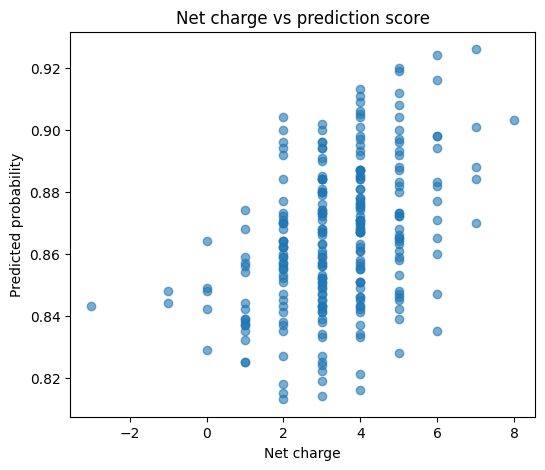

In [ ]:
plt.figure(figsize=(6,5))
plt.scatter(
    df["net_charge"],
    df["Pred_prob_1"],
    alpha=0.6
)
plt.xlabel("Net charge")
plt.ylabel("Predicted probability")
plt.title("Net charge vs prediction score")
plt.show()

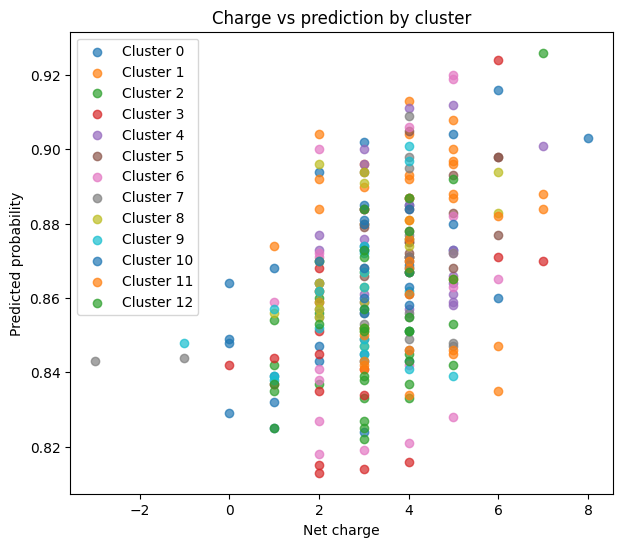

In [ ]:
plt.figure(figsize=(7,6))
for cluster_id, subdf in df.groupby("Cluster"):
    plt.scatter(
        subdf["net_charge"],
        subdf["Pred_prob_1"],
        label=f"Cluster {cluster_id}",
        alpha=0.7
    )
plt.xlabel("Net charge")
plt.ylabel("Predicted probability")
plt.title("Charge vs prediction by cluster")
plt.legend()
plt.show()

In [12]:
df.groupby("Cluster")["net_charge"].describe()

,count,mean,std,min,25%,50%,75%,max
Cluster,,,,,,,,
0,20.0,2.30,1.625455,0.0,1.00,2.5,4.00,5.0
1,20.0,3.85,1.268028,2.0,3.00,4.0,5.00,7.0
2,20.0,2.80,1.472556,1.0,2.00,3.0,4.00,7.0
3,20.0,2.85,1.785173,0.0,2.00,2.0,3.25,7.0
4,20.0,3.90,1.333772,2.0,3.00,4.0,5.00,7.0
5,20.0,4.25,0.966546,3.0,4.00,4.0,5.00,6.0
6,20.0,3.45,1.503505,1.0,2.00,3.5,5.00,6.0
7,20.0,3.15,1.980829,-3.0,3.00,4.0,4.00,5.0
8,20.0,2.95,1.276302,1.0,2.00,3.0,3.00,6.0


In [ ]:
cluster_corrs = (
    df.groupby("Cluster")
      .apply(lambda x: x["net_charge"].corr(x["Pred_prob_1"]))
)
print(cluster_corrs)

Cluster
0     0.441201
1     0.086565
2     0.525078
3     0.516199
4     0.098469
5     0.299645
6     0.326211
7     0.355262
8     0.468916
9     0.325391
10    0.538739
11    0.179343
12    0.273055
dtype: float64


C:\Users\ankit\AppData\Local\Temp\ipykernel_18112\1393456088.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x["net_charge"].corr(x["Pred_prob_1"]))


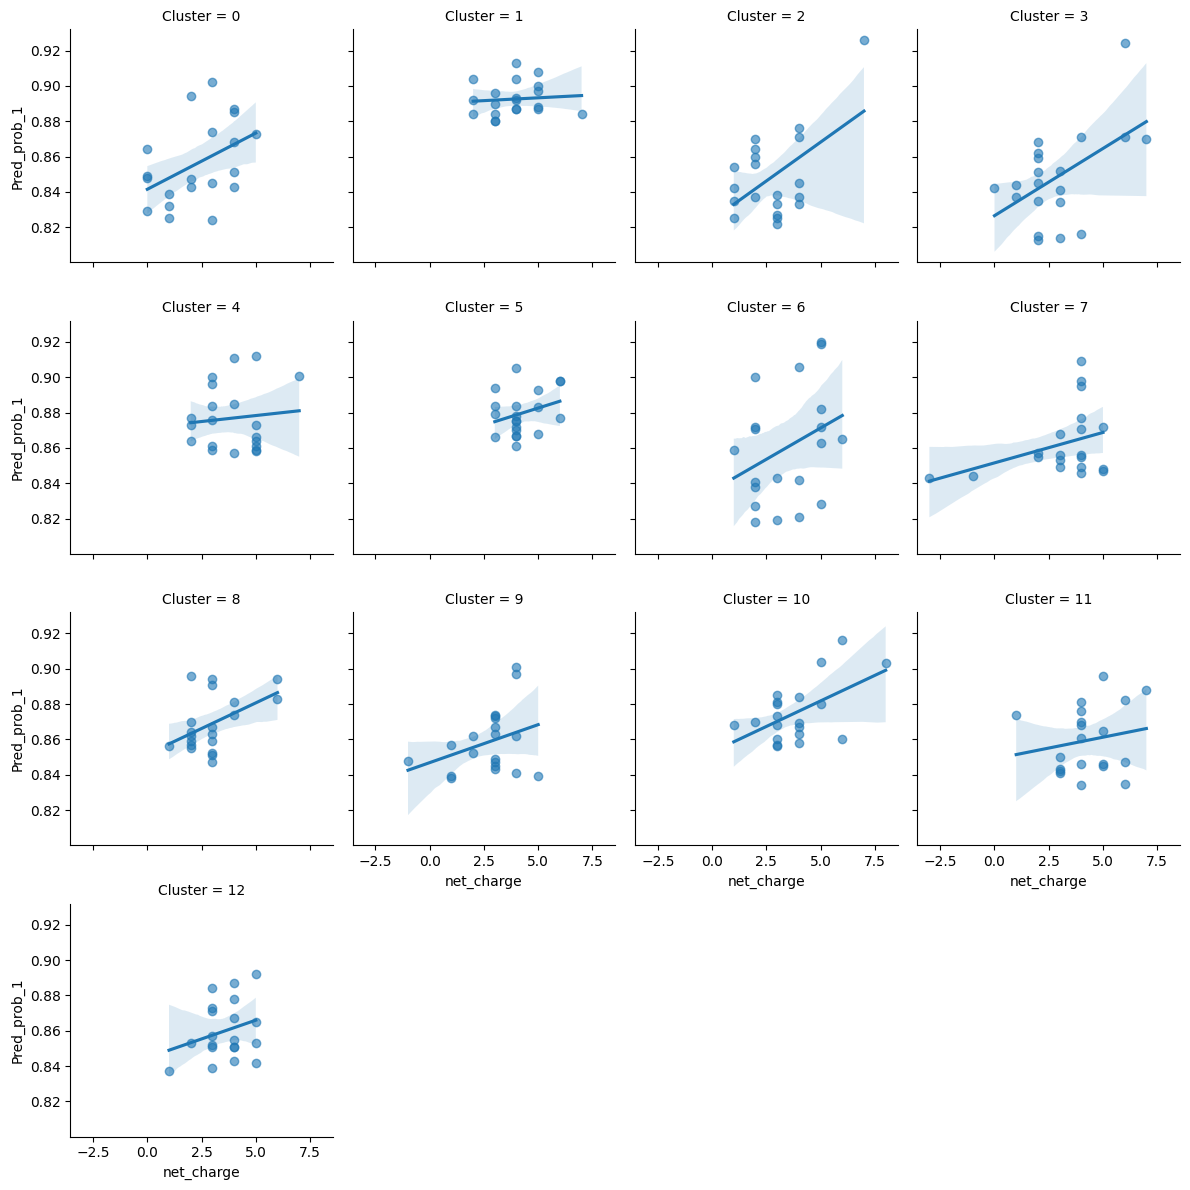

In [17]:
sns.lmplot(
    data=df,
    x="net_charge",
    y="Pred_prob_1",
    col="Cluster",
    col_wrap=4,
    height=3,
    scatter_kws={"alpha":0.6}
)

plt.show()